Project-Amazon Bestselling Books analysis

Dataset Overview

1.Name-The name of the book

2.Author-the writer of that book

3.User Rating-The Rating which is given by the buyer after reading

4.Reviews-the total number of reviewers who had given the reviews

5.Price-The total price of the book

6.Year-The year of Publication,

7.Genre-The category of the book

Importing all libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing the Files

In [4]:
data=pd.read_csv("C:/Users/91798/Downloads/bestsellers with categories.csv")
amazon=pd.DataFrame(data)

In [5]:
amazon

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


Handling of Missing/Null values

In [6]:
#Checking for null values
amazon.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [7]:
#Checking for Duplicate values
amazon.duplicated().sum()

np.int64(0)

Exploratory Data Analysis

In [36]:
#Evaluating genre wise Average-user-rating
amazon.groupby('Genre')['User Rating'].mean()

Genre
Fiction        4.648333
Non Fiction    4.595161
Name: User Rating, dtype: float64

In [37]:
#Identifying top 5 best authors based on Average Review Rating
groupwise=amazon.groupby('Author')['User Rating'].mean().sort_values(ascending=False)

In [10]:
groupwise.head(5)

Author
Alice Schertle           4.9
Bill Martin Jr.          4.9
Chip Gaines              4.9
Dav Pilkey               4.9
Emily Winfield Martin    4.9
Name: User Rating, dtype: float64

In [46]:
#Identify worst 5 lowest sellers
lowest_sellers=amazon.groupby('Name')['User Rating'].mean().sort_values(ascending=True).head(5)

In [45]:
lowest_sellers

Name
The Casual Vacancy                                                                          3.3
Go Set a Watchman: A Novel                                                                  3.6
Fifty Shades of Grey: Book One of the Fifty Shades Trilogy (Fifty Shades of Grey Series)    3.8
The Goldfinch: A Novel (Pulitzer Prize for Fiction)                                         3.9
Allegiant                                                                                   3.9
Name: User Rating, dtype: float64

In [47]:
#Evaluating top 5 Best sellers
top_five_bestsellers=amazon.groupby('Name')['User Rating'].mean().sort_values(ascending=False).head(5)

In [48]:
top_five_bestsellers

Name
Wrecking Ball (Diary of a Wimpy Kid Book 14)                                       4.9
Brown Bear, Brown Bear, What Do You See?                                           4.9
Dog Man: Lord of the Fleas: From the Creator of Captain Underpants (Dog Man #5)    4.9
The Wonderful Things You Will Be                                                   4.9
The Very Hungry Caterpillar                                                        4.9
Name: User Rating, dtype: float64

In [49]:
#Identifying year wise best seller
Avg_ratings=amazon.groupby(['Year','Name'])['User Rating'].mean().reset_index()

In [17]:
Avg_ratings

,Year,Name,User Rating
0,2009,"Act Like a Lady, Think Like a Man: What Men Re...",4.6
1,2009,Arguing with Idiots: How to Stop Small Minds a...,4.6
2,2009,"Breaking Dawn (The Twilight Saga, Book 4)",4.6
3,2009,Crazy Love: Overwhelmed by a Relentless God,4.7
4,2009,Dead And Gone: A Sookie Stackhouse Novel (Sook...,4.6
...,...,...,...
542,2019,Unicorn Coloring Book: For Kids Ages 4-8 (US E...,4.8
543,2019,What Should Danny Do? (The Power to Choose Ser...,4.8
544,2019,Where the Crawdads Sing,4.8
545,2019,Wrecking Ball (Diary of a Wimpy Kid Book 14),4.9


In [18]:
idx=Avg_ratings.groupby('Year')['User Rating'].idxmax()

In [19]:
year_wise_bestsellers=Avg_ratings.loc[idx]

In [20]:
year_wise_bestsellers=year_wise_bestsellers.sort_values('Year',ascending=False)

In [21]:
year_wise_bestsellers

,Year,Name,User Rating
499,2019,"Brown Bear, Brown Bear, What Do You See?",4.9
453,2018,Dog Man and Cat Kid: From the Creator of Capta...,4.9
401,2017,"Brown Bear, Brown Bear, What Do You See?",4.9
361,2016,Hamilton: The Revolution,4.9
317,2015,Humans of New York : Stories,4.9
264,2014,Jesus Calling: Enjoying Peace in His Presence ...,4.9
211,2013,"Goodnight, Goodnight Construction Site (Hardco...",4.9
159,2012,"Goodnight, Goodnight Construction Site (Hardco...",4.9
115,2011,Jesus Calling: Enjoying Peace in His Presence ...,4.9
69,2010,Percy Jackson and the Olympians Paperback Boxe...,4.8


In [50]:
amazon.groupby('Genre')['Price'].sum()

Genre
Fiction        2604
Non Fiction    4601
Name: Price, dtype: int64

In [51]:
#Evaluating year-wise genre sales
year_wise_genre_sales=amazon.groupby(['Year','Genre'])['Price'].sum().reset_index()

In [26]:
year_wise_genre_sales

,Year,Genre,Price
0,2009,Fiction,374
1,2009,Non Fiction,396
2,2010,Fiction,194
3,2010,Non Fiction,480
4,2011,Fiction,244
5,2011,Non Fiction,511
6,2012,Fiction,258
7,2012,Non Fiction,507
8,2013,Fiction,257
9,2013,Non Fiction,473


In [52]:
#Top 5 Books based on review count
top_5_reviews_count=amazon.groupby(['Genre','Name'])['Reviews'].sum().sort_values(ascending=False).head(5).reset_index()

In [29]:
top_5_reviews_count

,Genre,Name,Reviews
0,Fiction,The Fault in Our Stars,201928
1,Fiction,"Oh, the Places You'll Go!",174672
2,Fiction,Gone Girl,171813
3,Fiction,The Girl on the Train,158892
4,Non Fiction,"Unbroken: A World War II Story of Survival, Re...",148365


In [53]:
#Evaluating bottom 5 books based on review count
Bottom_5_reviews_count=amazon.groupby(['Genre','Name'])['Reviews'].sum().sort_values(ascending=True).head(5).reset_index()

In [32]:
Bottom_5_reviews_count

,Genre,Name,Reviews
0,Non Fiction,Divine Soul Mind Body Healing and Transmission...,37
1,Non Fiction,Soul Healing Miracles: Ancient and New Sacred ...,220
2,Non Fiction,George Washington's Sacred Fire,408
3,Non Fiction,True Compass: A Memoir,438
4,Non Fiction,The Daily Show with Jon Stewart Presents Earth...,440


Data Visualization

1.Average User Rating Based on Genre

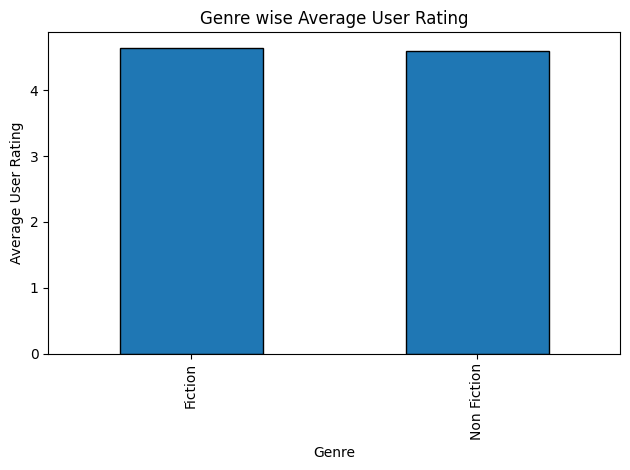

In [8]:
a1=amazon.groupby('Genre')['User Rating'].mean().plot(kind='bar',edgecolor='black')
plt.ylabel('Average User Rating')
plt.title('Genre wise Average User Rating')
plt.tight_layout()
plt.savefig("a1.png")

2.Top 5 Best Authors based on Average Review Rating

Text(0.5, 1.0, 'Top 5 Best Authors')

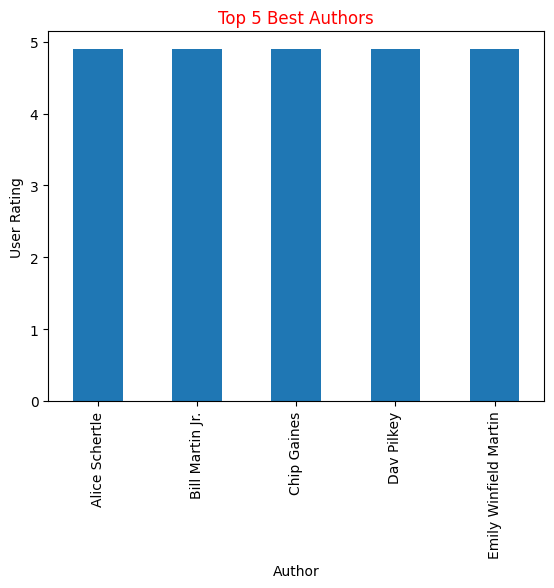

In [11]:
groupwise.head(5).plot(kind='bar')
plt.ylabel('User Rating')
plt.title('Top 5 Best Authors',color='r')

3.Bottom 5 Lowest Sellers

Text(0.5, 1.0, 'Lowest Selling Books')

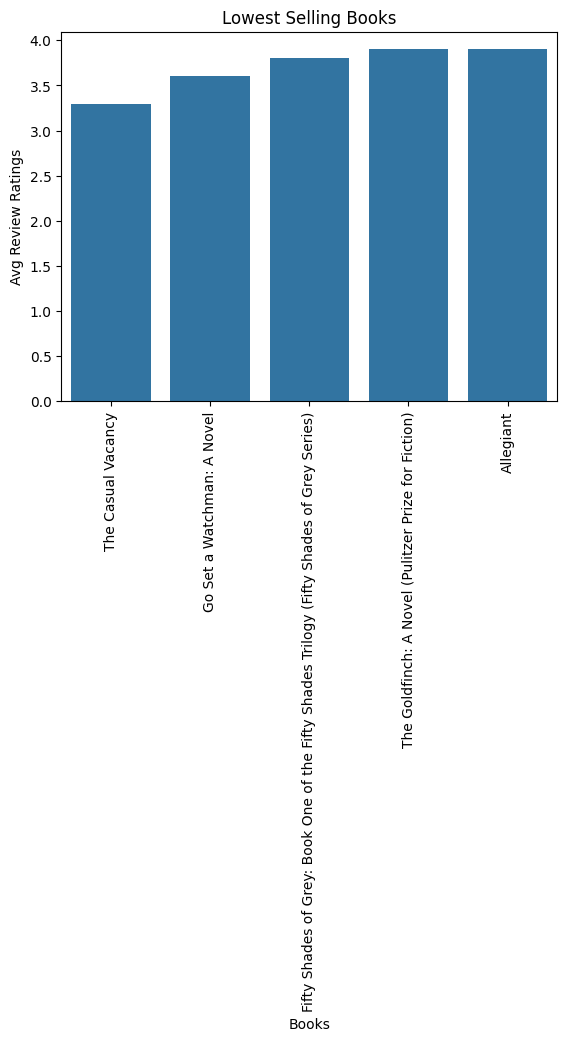

In [12]:
lowest_sellers=amazon.groupby('Name')['User Rating'].mean().sort_values(ascending=True).head(5)
sns.barplot(data=lowest_sellers)
plt.xlabel('Books',size=10)
plt.xticks(rotation=90)
plt.ylabel('Avg Review Ratings')
plt.title('Lowest Selling Books')

4.Top 5 Best Selling Books

Text(0.5, 1.0, 'Top 5 Best Selling Books')

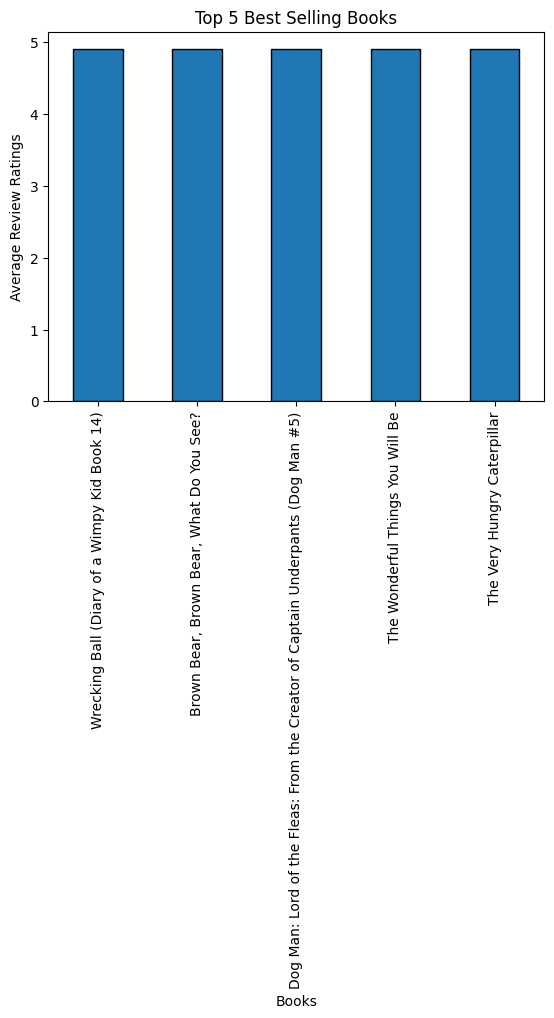

In [15]:
top_five_bestsellers.plot(kind='bar',edgecolor='black')
plt.xlabel('Books')
plt.ylabel('Average Review Ratings')
plt.title('Top 5 Best Selling Books')


5.Year Wise Best Sellers

Text(0.5, 1.0, 'Year Wise Best Sellers')

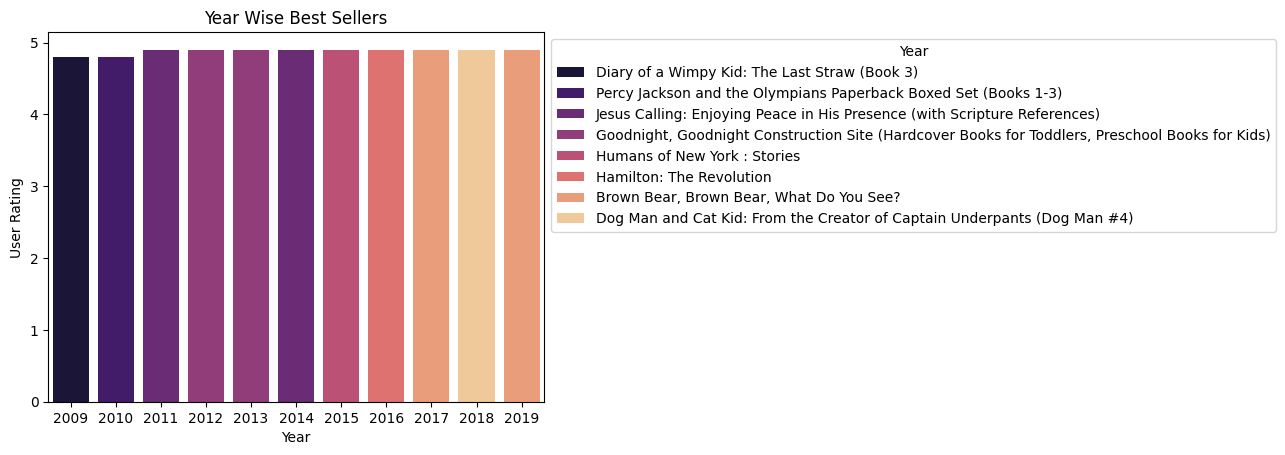

In [56]:
ax=sns.barplot(
    data=year_wise_bestsellers, 
    x='Year', 
    y='User Rating', 
    hue='Name',      
    palette='magma'   
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Year")
plt.title('Year Wise Best Sellers')

6.Genre Wise Overall Sales of Books

(array([0, 1]), [Text(0, 0, 'Fiction'), Text(1, 0, 'Non Fiction')])

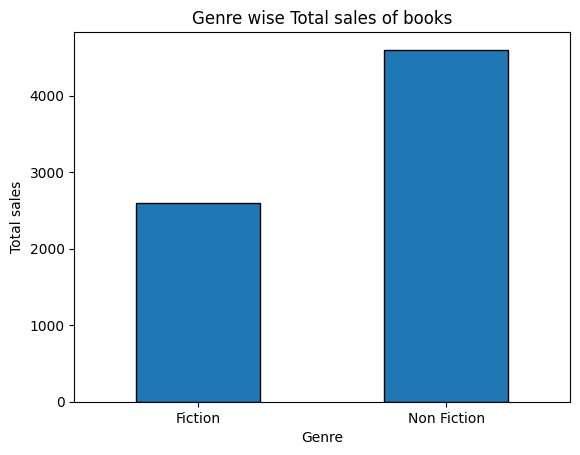

In [24]:
amazon.groupby('Genre')['Price'].sum().plot(kind='bar',edgecolor='black')
plt.ylabel('Total sales')
plt.title('Genre wise Total sales of books')
plt.xticks(rotation=360)

7.Year Wise Comparison of Genre Sales of Books

Text(0.5, 1.0, 'Year Wise Comparison of Genre Sales of Books')

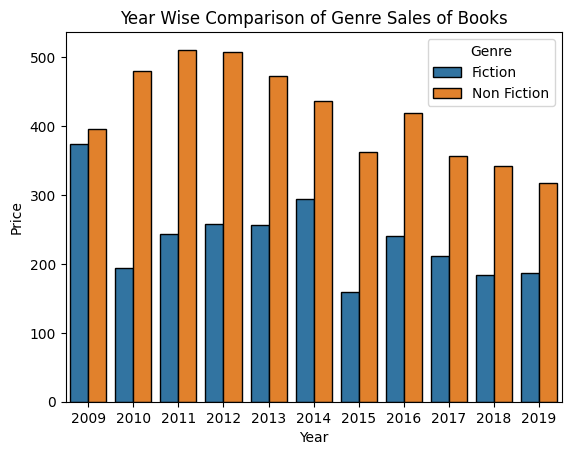

In [55]:
sns.barplot(data=year_wise_genre_sales,x='Year',y='Price',hue='Genre',edgecolor='black')
plt.title('Year Wise Comparison of Genre Sales of Books')

8.Top 5 Books based on the Overall Count of Reviews

Text(0.5, 1.0, 'Top 5 Books based on the Overall Count of Reviews')

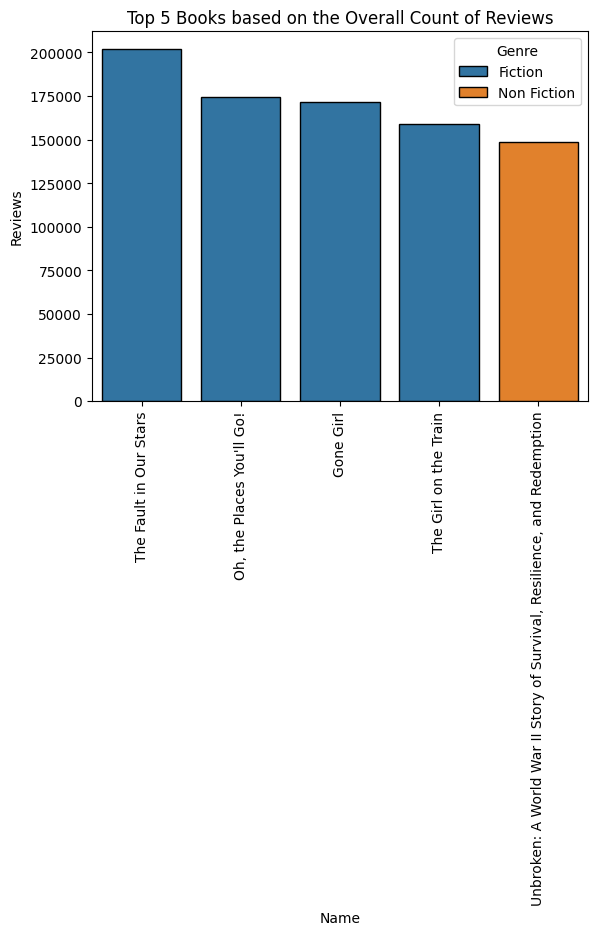

In [54]:
sns.barplot(data=top_5_reviews_count,x='Name',y='Reviews',hue='Genre',edgecolor='black')
plt.xticks(rotation=90)
plt.title('Top 5 Books based on the Overall Count of Reviews')

9.Bottom 5 Books Based on the Review Counts

Text(0.5, 1.0, 'Low Review Counts')

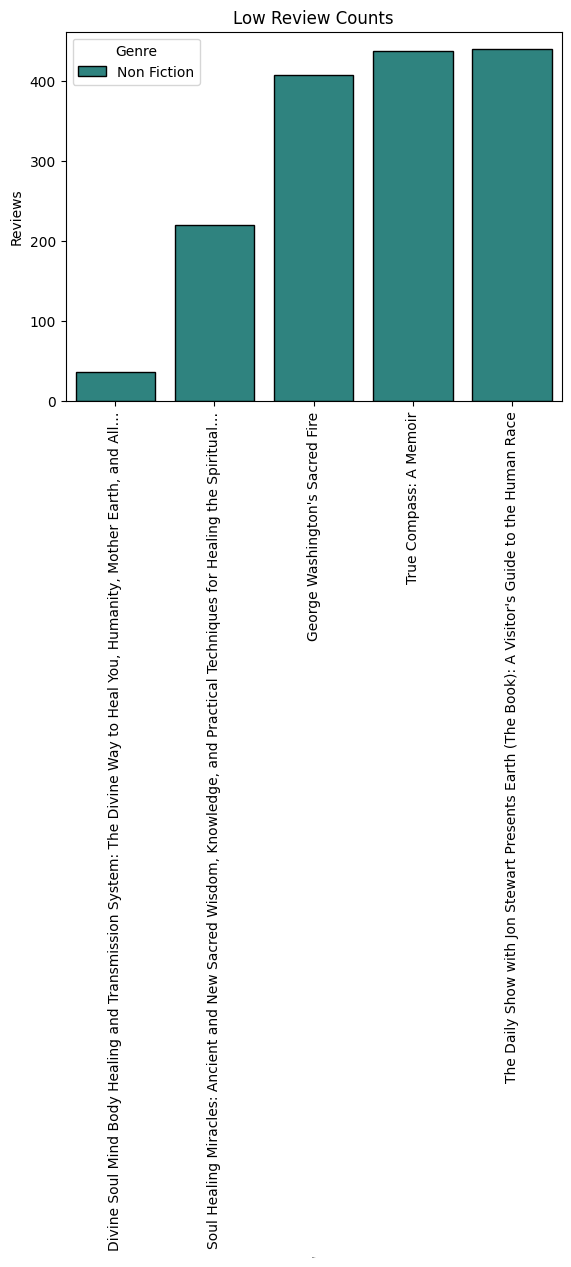

In [33]:
sns.barplot(data=Bottom_5_reviews_count,x='Name',y='Reviews',hue='Genre',edgecolor='Black',palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Books',size=0.001)
plt.title('Low Review Counts')

Key findings and insights